## Fig 1: Volcano Plot

In [79]:
# Data: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE57736

In [80]:
# Importing libraries required for the data analysis
# pandas: provides perform data cleaning and preprocessing (e.g., handling missing values, filtering rows/columns),used To read and write datasets (e.g., CSV, Excel)    
# numpy: offers efficient and fexible operations on numerical arrays and matrices. Perform mathematical and statistical computations on datasets (e.g., mean, standard deviation)
# statsmodels.stats.multitest: perform corrections (e.g., Bonferroni or Benjamini-Hochberg methods) when conducting multiple hypothesis tests to reduce false-positive rates
# scipy.stats.ttest_ind: part of the SciPy library, which provides statistical tools and scientific computations. The ttest_ind function specifically performs independent two-sample t-tests
# matplotlib.pyplot: to create visual representations of data (e.g., scatter plots, line charts, histograms)

import pandas as pd
import numpy as np
from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_ind
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt

In [81]:
#Step 1: Load expression and metadata data using pd.read_csv function
expression_data = pd.read_csv('expression_data.csv')
#To load metadata, the parameter index_col=0 is specified so that first column can be used as the row labels (index) for the resulting DataFrame
metadata_data = pd.read_csv('metadata_data.csv', index_col=0)

#Print and preview the expression data 
expression_data.head()

,GENE_SYMBOL,GSM1387822,GSM1387823,GSM1387824,GSM1387825,GSM1387826,GSM1387827,GSM1387828,GSM1387829,GSM1387830,GSM1387831,GSM1387832,GSM1387833,GSM1387834,GSM1387835,GSM1387836
0,NaN,0.874004,0.549556,-0.697257,0.415050,-0.827649,-0.535486,0.232251,0.143519,-0.347015,0.045042,0.000000,1.638397,-0.021731,-0.588089,-0.884324
1,NaN,1.834714,1.452515,-0.373162,1.097279,-1.108419,-0.958202,-0.083212,0.078793,0.000000,0.051562,0.001763,2.867832,-0.302325,-0.622700,-1.149076
2,NaN,2.100987,1.644360,-0.285785,1.318780,-0.849151,-0.532083,0.375632,0.128208,-0.442803,0.000000,-0.087541,1.410189,0.050498,-0.722111,-1.079270
3,NaN,2.056458,1.581918,-0.375929,1.284894,-0.684192,-0.505746,0.568403,0.105348,-0.318298,-0.003019,0.000000,1.751951,0.307325,-0.464979,-0.721359
4,NaN,1.894224,1.535799,-0.130214,1.236697,-0.717004,-0.419575,0.400018,0.060410,-0.399344,0.000000,-0.058504,1.441496,0.046378,-0.709648,-0.900831


In [82]:
#Step 2: Prep-processing and cleaning the data
#As seen in above preview, some Gene_Symbol column has NaN values, so it is necessary to remove these before analysis 
#Remove NaN values in 'GENE_SYMBOL'using not.na()
#This line of code filters out rows in the expression_data DataFrame where the 'GENE_SYMBOL' column has NaN (missing) values
expression_data = expression_data[expression_data['GENE_SYMBOL'].notna()]  

#Remove blank spaces in 'GENE_SYMBOL'contain only blank spaces or is empty after trimming leading and trailing spaces
#!= "": checks if the stripped values are not empty strings
expression_data = expression_data[expression_data['GENE_SYMBOL'].str.strip() != ""] 

#This code is used to group expression data by genes and calculate mean value for same genes
#groupby('GENE_SYMBOL'): groups the DataFrame expression_data by unique values in the 'GENE_SYMBOL' column
#.mean(numeric_only=True): computes the mean for each numeric column in the groups, ignoring non-numeric columns
#.reset_index(): move the 'GENE_SYMBOL' column the index
expression_data = expression_data.groupby('GENE_SYMBOL').mean(numeric_only=True).reset_index()

#This was used as i was getting error of non-numeric values in the data
#apply(pd.to_numeric): converts all columns in expression_data to numeric data types. If a column contains non-numeric values, they are converted to NaN (Not a Number)
#errors='coerce': ensures that invalid parsing (e.g., non-numeric strings) is handled gracefully by replacing them with NaN
expression_data = expression_data.apply(pd.to_numeric, errors='coerce')

In [83]:
#Step 3: Perform Differential gene expression analysis

#Extract groups
#Filters the DataFrame to include only rows where the value in the 'condition' column is 'Latent TB'
#metadata_data[condition] selects the rows of the DataFrame that meet the condition
#.index extracts the index of the filtered rows
#so group1 will contain Latent TB condition and group2 will contain Pulmonary TB condition
group1 = metadata_data[metadata_data['condition'] == 'Latent TB'].index
group2 = metadata_data[metadata_data['condition'] == 'Pulmonary TB'].index

#Initialize an empty results DataFrame
results = []

#This loop is used to iterate through each gene (row) in the expression_data DataFrame for the analysis
for gene in expression_data.index:
    #Get expression values for the two groups
    #This line of code extract expression values for the current gene from the two groups (group1 and group2), based on the indices defined earlier
    group1_values = expression_data.loc[gene, group1]
    group2_values = expression_data.loc[gene, group2]
    
    #Perform t-test using ttest_ind()
    #Performs an independent two-sample t-test between the values of the two groups for the current gene
    #Calculated t-statisc to quantify the difference between the group means in terms of standard error and 
    #p_value for observing the data if the null hypothesis (no difference) is true
    t_stat, p_value = ttest_ind(group1_values, group2_values, equal_var=False)
    
    #Calculate log2 fold change
    #Compute the log2 fold change (log2FC) as the difference between the means of the two groups
    #The log2FC quantifies the difference in gene expression levels between the two groups (e.g., Pulmonary TB vs. Latent TB) in a biologically interpretable way
    #A higher log2FC indicates that the gene is expressed more in group2 compared to group1, and vice versa for a negative value
    log2fc = group2_values.mean() - group1_values.mean()
    
    #Store results in a dataframe
    #This line of code append the results for the current gene (gene name, log2 fold change, and p-value) to a list called results
    results.append({'gene': gene, 'log2FC': log2fc, 'p_value': p_value})

#Convert results to DataFrame
results_df = pd.DataFrame(results)

#Apply Benjamini-Hochberg correction 
#multipletests: Adjusts the p-values for multiple testing using the Benjamini-Hochberg method to control the false discovery rate (FDR)
#results_df['p_value']: this takes the raw p-values for each gene, calculated earlier using the t-test
#method='fdr_bh': Specifies the Benjamini-Hochberg correction method
#[1]: extracts the adjusted p-values from the function's output
results_df['adjusted_p_value'] = multipletests(results_df['p_value'], method='fdr_bh')[1]

#Filter DEGs to get significant genes
#deg based on specific thresholds for log2 fold change (log2FC) and p-value is saved in a dataframe deg_results 
deg_results = results_df[(abs(results_df.log2FC) > 1.0) & (results_df.p_value < 0.05)]
deg_results.head(5)

,gene,log2FC,p_value,adjusted_p_value
24,24,-1.016147,0.022519,0.482051
51,51,-1.080472,0.000228,0.225767
83,83,1.057832,0.006776,0.430471
123,123,1.029548,0.005091,0.430471
286,286,1.109745,0.037839,0.508345


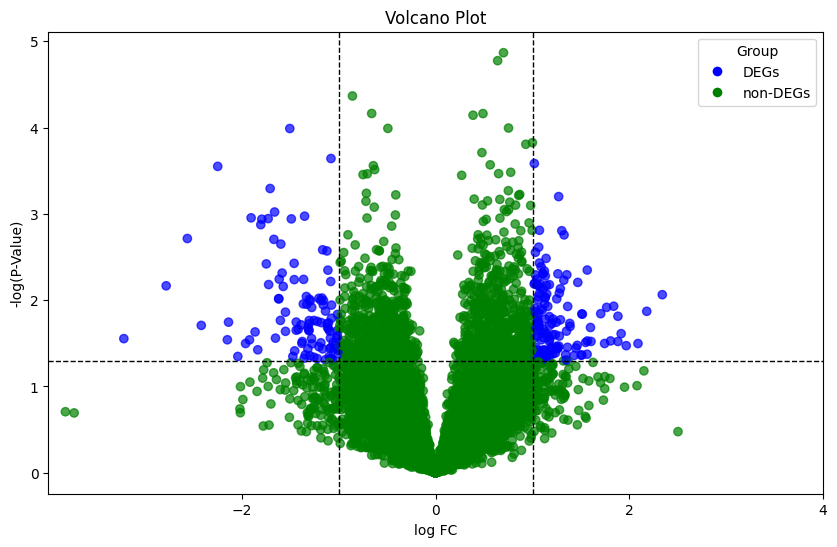

In [84]:
#Step 4: Plot the Volcano Plot
#This code adds a new column named color to the results_df DataFrame, categorizing each gene as either a differentially expressed gene (DEG) or non-differentially expressed gene (Non-DEG) based on specific criteria for log2 fold change (log2FC) and p-value
#results_df.apply(...): applies the function (in this case, a lambda function) to each row of the DataFrame
#axis=1: Specifies that the function is applied row-wise (i.e., each row is passed as input to the function)
#abs(x.log2FC) > 1.0: checks if the absolute value of the log2 fold change is greater than 1.0, indicating a biologically significant change
#x.p_value < 0.05: Checks if the p-value is less than 0.05, indicating statistical significance
#If both conditions are true: The row is classified as a DEG and labeled 'DEG'
#Otherwise: The row is labeled 'Non-DEG'
results_df['color'] = results_df.apply(lambda x: 'DEG' if (abs(x.log2FC) > 1.0 and x.p_value < 0.05) else 'Non-DEG', axis=1)


#Plot
#plt.figure(...): Initializes a new figure for the plot
#figsize=(10, 6): Sets the width and height of the plot in inches (10 inches wide and 6 inches tall)
plt.figure(figsize=(10, 6))
#This code creates a scatter plot using Matplotlib to visualize the results of differential gene expression analysis called volcano plot
#plt.scatter(...): Creates a scatter plot
#results_df['log2FC']: Represents the x-axis values (log2 fold change)
#-np.log10(results_df['p_value']): Represents the y-axis values (negative log10 of the p-value)
#c=results_df['color'].map({...}): Maps the color column to specific colors for plotting:'Non-DEG' is mapped to green and 'DEG' is mapped to blue
plt.scatter(results_df['log2FC'], -np.log10(results_df['p_value']), 
            c=results_df['color'].map({'Non-DEG': 'green', 'DEG': 'blue'}), alpha=0.7)

#Add horizontal and vertical threshold lines
plt.axhline(y=1.3, color='black', linestyle='--', linewidth=1)  
plt.axvline(x=-1, color='black', linestyle='--', linewidth=1)  
plt.axvline(x=1, color='black', linestyle='--', linewidth=1) 
#Add title to the plot
plt.title("Volcano Plot")

#Add legend inside the plot box in the upper-right corner
#Used Line2D: it allows to define custom markers, colors, and sizes that can be added to a plot's legend without actually plotting them on the graph
#marker='o': Specifies that the marker should be a circle
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='DEGs', markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='non-DEGs', markerfacecolor='green', markersize=8)
]
#Specifies the items to include in the legend
#adds a customized legend to the plot using the legend_elements
plt.legend(handles=legend_elements, title="Group", loc='upper right', fontsize=10, title_fontsize=10)

#Set x-axis and y-axis range and label
plt.xlim(-4, 4)
plt.xticks([-2, 0, 2, 4])
plt.xlabel("log FC")
plt.ylabel("-log(P-Value)")
plt.grid(False)
plt.show()

In [85]:
#The x-axis represents the log2 fold change (log2FC), which shows the amount of change in gene expression between two circumstances (such as latent TB and pulmonary TB) 
#The y-axis represents the -log10 p-value, which indicates the statistical significance of the expression changes
#The differentially expressed genes (DEGs) are indicated by blue coloured nodes
#Green coloured nodes are represented as non-differentially expressed genes (non-DEGs) that do not meet the significance criteria.

## Fig 2: PCA Plot

In [86]:
#Data: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE39375

In [87]:
#Import necessary libraries
#
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [88]:
#Step 1: Load the datasets for analysis using pd.read_csv()
expression_data = pd.read_csv("GSE39375_counts_matrix.csv")
annotation_data = pd.read_csv("GSE39375_annotation_file.csv")
metadata_data = pd.read_csv('GSE3975_metadata.csv')
print(expression_data.head())

             ID  GSM967008  GSM967009  GSM967010  GSM967011  GSM967012  \
0    1415670_at     1449.9      860.7     1501.6     1967.0     2003.1   
1    1415671_at     5735.0     5147.5     5281.8     5771.1     5393.7   
2    1415672_at     3214.3     3264.9     3179.1     3140.4     3105.2   
3    1415673_at      450.8      518.2      681.6      760.8      727.6   
4  1415674_a_at     2133.6     2439.7     2520.1     1788.7     2497.4   

   GSM967013  GSM967014  GSM967015  GSM967016  GSM967017  
0     2102.0     2920.4     1341.0     1600.1     1173.6  
1     5541.5     5469.8     3809.6     8242.5     5610.0  
2     3041.7     2900.6     2019.1     2636.5     3238.9  
3      643.5      579.2      329.0      536.1      279.8  
4     1469.8     1788.0     1673.7     1881.6     1534.3  


In [89]:
#Step 2: Pre-processing and Normalization
#Remove NA values using .dropna()
expression_data = expression_data.dropna()
gene_symbols = annotation_data.dropna()

#Mapping gene symbols using probe_ID. One gene symbol may correspond to one or more probe_IDs 
#Merge the expression datawith the gene symbols data to associate 'probe_id' with 'gene_symbol' using .merge()
merge_df = expression_data.merge(gene_symbols, on="ID")

#Group by 'gene_symbol' and compute the mean for each gene using .mean() and keep numeric_only = TRUE to make sure all have numeric values
expression_data = merge_df.groupby("Gene Symbol").mean(numeric_only = True)

#This section of code scales the expression_data DataFrame using the MinMaxScaler to transform the data into a specified range, 
#making it easier to work with numerical values during analyses such as clustering
#MinMaxScaler: A scaling method from the sklearn.preprocessing module that transforms data to a specified range by linearly scaling each feature
#Initialize the scaler
#feature_range=(0, 2): specifies the range of the transformed data
scaler = MinMaxScaler(feature_range=(0, 2))  

#Apply scaling ensures that all features are on a similar scale, which is crucial for algorithms 
#like clustering and machine learning models sensitive to magnitude such as PCA
#pd.Dataframe: converts the scaled data (a NumPy array) back into a pandas DataFrame
scaled_expression_data = pd.DataFrame(
    #fit: Calculates the minimum and maximum values of each column in the expression_data DataFrame
    #transform: Applies the scaling formula to each value in the DataFrame
    #The resulting array contains the scaled values for all rows and columns
    scaler.fit_transform(expression_data), 
    #Retain original row names (gene symbols) from expression dataframe
    index=expression_data.index, 
    #Retain original column names (samples) from expression dataframe
    columns=expression_data.columns         
)

#Printt the scaled expression data
print(scaled_expression_data.head())

               GSM967008  GSM967009  GSM967010  GSM967011  GSM967012  \
Gene Symbol                                                            
0610005C13Rik   0.173958   0.214979   0.247726   0.125445   0.232630   
0610006L08Rik   0.001644   0.000360   0.000403   0.002073   0.001032   
0610007P14Rik   0.054237   0.105535   0.150725   0.108819   0.090799   
0610009B22Rik   0.163664   0.130583   0.141552   0.125302   0.147970   
0610009L18Rik   0.002668   0.006001   0.005012   0.004018   0.005065   

               GSM967013  GSM967014  GSM967015  GSM967016  GSM967017  
Gene Symbol                                                           
0610005C13Rik   0.064960   0.064692   0.088013   0.190865   0.143892  
0610006L08Rik   0.000572   0.000927   0.000037   0.001382   0.000079  
0610007P14Rik   0.050920   0.067819   0.045193   0.050928   0.049671  
0610009B22Rik   0.084920   0.103591   0.057727   0.096449   0.073138  
0610009L18Rik   0.000829   0.003300   0.001669   0.001169   0.001674 

In [90]:
#Step 3: Perform PCA
#PCA: A dimensionality reduction technique from the sklearn.decomposition module
#This section of code performs PCA on the scaled expression data to reduce its dimensionality to two principal components for each sample
#n_components=2: specifies the number of principal components to compute. After transformation, the data will be projected into a two-dimensional space
pca = PCA(n_components=2)
#As scaled_expression_data has genes as rows and samples as columns, transpose to have samples as rows using .T
#For PCA, the input needs samples as rows and features (genes) as columns because PCA operates on the covariance matrix of features
#fit: calculates the principal components based on the covariance matrix of the transposed data
#transform: take the original data onto the principal component axes to reduce its dimensionality
#pca_result: A 2D NumPy array where each row represents a sample and each column represents one of the two principal components
pca_result = pca.fit_transform(scaled_expression_data.T)  

#Create a DataFrame with PCA results
#pd.DataFrame(...): converts the 2D NumPy array pca_result (output of PCA) into a pandas DataFrame
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
#expression_data.columns: contains the sample identifiers (e.g., Sample1, Sample2, etc.) from the original data
#pca_df['Sample_ID']: Adds a new column to pca_df with these sample identifiers, associating each sample with its PCA coordinates
pca_df['Sample_ID'] = expression_data.columns
#merge(on='Sample_ID'): combines pca_df with metadata_data by matching rows based on the Sample_ID column
pca_df = pca_df.merge(metadata_data, on='Sample_ID')

print(pca_df.head())

        PC1       PC2  Sample_ID Condition
0  0.154911 -1.013829  GSM967008     obese
1  3.178681  0.202326  GSM967009      lean
2  5.373351  0.475190  GSM967010     obese
3  0.176930 -2.029526  GSM967011      lean
4  4.163102  0.456804  GSM967012     obese


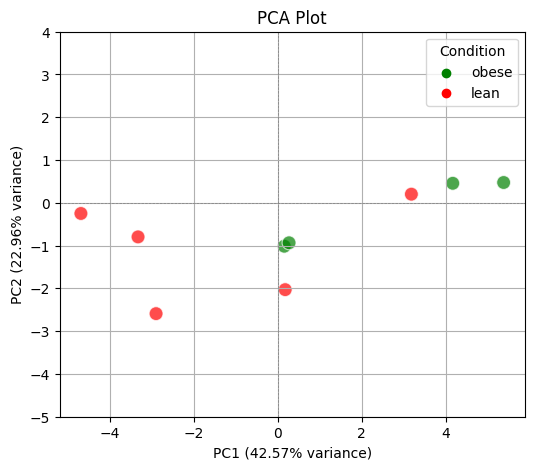

In [91]:
#Step 4: Plot PCA
##plt.figure(...): Initializes a new figure for the plot
#figsize=(6, 5): Sets the width and height of the plot in inches (6 inches wide and 5 inches tall)
plt.figure(figsize=(6, 5))
#sns.scatterplot(...): creates a scatter plot using Seaborn
#data=pca_df: Specifies the DataFrame (pca_df) containing the PCA results 
#hue: color-codes points based on the Condition column in pca_df
#palette: define colour for ech condition. Representing 'lean' are red, and 'obese' are green
#s=100: sets the size of the scatter points to 100 
#alpha=0.7 means 70% opacity and 30% transparent
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Condition',  
    style='Condition',
    markers={'lean': 'o', 'obese': 'o'},
    palette={'lean': 'red', 'obese': 'green'},
    s=100,
    alpha=0.7
)

#Add title and label in the plot 
plt.title('PCA Plot')
#this section of code contains the proportion of variance explained by each principal component
#pca.explained_variance_ratio_[0]: Variance explained by PC1 
#pca.explained_variance_ratio_[1]: Variance explained by PC2 
#The variance percentage is multiplied by 100 and formatted to 2 decimal places using : .2f
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)')
#Add refrence line and set colour
plt.axhline(0, color='grey', linestyle='--', linewidth=0.5)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.5)
#This line of code adds a legend to the plot to describe the visual encoding, in this case obese and lean
plt.legend(title='Condition')
plt.ylim(-5, 4) 
#Add grid 
plt.grid(True)
#Display the pot
plt.show()

In [92]:
#PCA plot to visualise lean and obese samples from mice.
#There is some degree of separation between the red coloured points (lean samples) and green coloured points (obese samples) along PC1, indicating that the principal component captures variations between these two situations